### 🚀 Asteroid Diameter Prediction – Hybrid Model

This notebook focuses on preparing data and building hybrid models to predict asteroid diameters using various regression techniques. We use a cleaned dataset and apply exploratory data analysis (EDA), outlier handling, and log transformation (only for diameter) before training.
- It is a two-step model:
  - First make a model to predict 'albedo' and use it to fill in missing 'albedo's
  - Then use predicted albedo to predict 'diameter'

- This model can be used to predict 'diameter' using predicted 'albedo'.

---

#### 📦 Imports
We import necessary packages for regression modeling, visualization, preprocessing, and evaluation.

In [1]:
import pandas as pd
import numpy as np

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from catboost import Pool

# Explainability
import shap

# Model evaluation & tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#### 📑 Load Cleaned Asteroid Dataset
We load the preprocessed dataset and select rows where `albedo` values are available, which is important for the first regression.

In [2]:
asteroid = pd.read_csv('data/asteroid_cleaned.csv', index_col="full_name")

# Drop "diameter" feature
df = asteroid.drop(columns = ['diameter'])

# Extracting rows where albedo is present
df_alb = df[df['albedo'].notna()]

#### 📊 Visualizing Albedo Distribution
We inspect the distribution of target variable `albedo` using histograms.

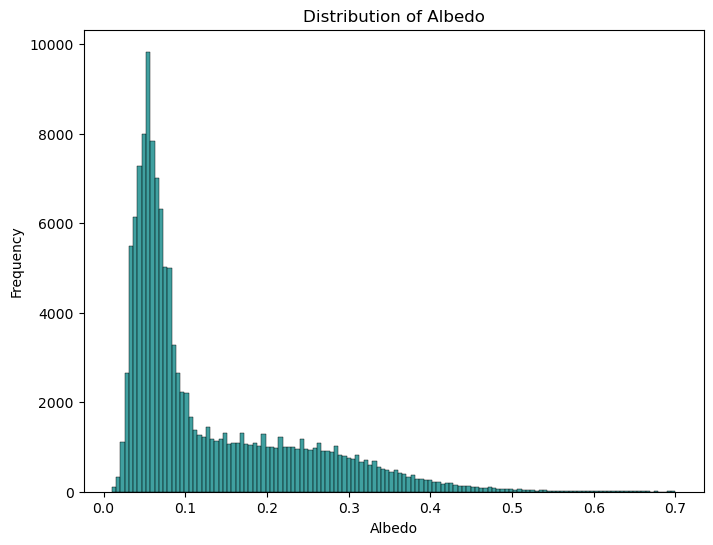

In [3]:
plt.figure(figsize=(8, 6))
sns.histplot(df_alb['albedo'], color='teal')
plt.title('Distribution of Albedo')
plt.xlabel('Albedo')
plt.ylabel('Frequency')
plt.show()

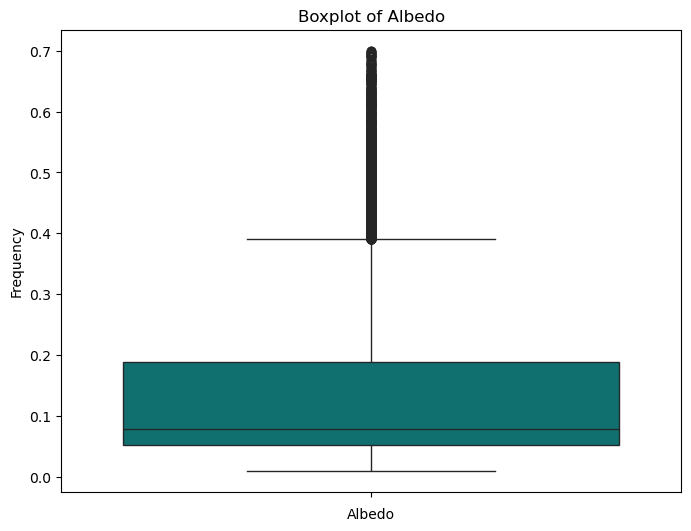

In [4]:
# Boxplot of log-transformed albedo
plt.figure(figsize=(8, 6))
sns.boxplot(df_alb['albedo'], color='teal')
plt.title('Boxplot of Albedo')
plt.xlabel('Albedo')
plt.ylabel('Frequency')
plt.show()

### 🧹 Outlier Removal

We filter extreme outliers (above the 99.75th percentile) are filtered out to prevent bias in training.

We then split the dataset into training and testing sets.

In [5]:
y = df_alb['albedo']

# Remove top 0.25% outliers
upper_bound = np.percentile(y, 99.75)
df_alb_filtered = df_alb[y <= upper_bound]

# Features and target
X_filtered = df_alb_filtered.drop('albedo', axis=1)
y_filtered = np.log1p(df_alb_filtered['albedo'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

### 🔍 Regression

We start with a basic linear regression model as a baseline. Then continue on to Random Forest, XGBoost, LightBGM and Catboost.

In [6]:
# 📈 LINEAR REGRESSION
# Training a simple linear regression model to establish a baseline.

# Initialize and train the model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = lin_model.predict(X_test)
y_train_pred = lin_model.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Train Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

Train Mean Squared Error: 0.0048, R² Score: 0.3639
Train Mean Squared Error: 0.0049, R² Score: 0.3592


In [7]:
# Random forest regression
# Using Random Forest to capture nonlinear relationships and interactions.

# # Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Train Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

Train Mean Squared Error: 0.0005, R² Score: 0.9401
Train Mean Squared Error: 0.0033, R² Score: 0.5757


In [8]:
# XGBOOST REGRESSION
# Applying XGBoost for powerful gradient boosting with regularization.

# Initialize and train XGBRegressor
xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
xgb_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = xgb_reg.predict(X_test)
y_train_pred = xgb_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Train Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

Train Mean Squared Error: 0.0026, R² Score: 0.6584
Train Mean Squared Error: 0.0034, R² Score: 0.5598


In [9]:
# LightBGM REGRESSION
# Training LightGBM for efficient gradient boosting with fast training.

# Initialize and train LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(objective='regression', random_state=42)
lgb_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = lgb_reg.predict(X_test)
y_train_pred = lgb_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set 
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

c:\Users\aj20j\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\aj20j\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4456
[LightGBM] [Info] Number of data points in the train set: 108534, number of used features: 30
[LightGBM] [Info] Start training from score 0.116405
Train Mean Squared Error: 0.0032, R² Score: 0.5859
Test  Mean Squared Error: 0.0034, R² Score: 0.5585


In [10]:
# Catboost regression
# Utilizing CatBoost for handling categorical features and boosting accuracy.

# Initialize and train CatBoost Regressor
cat_reg = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=500
)
cat_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = cat_reg.predict(X_test)
y_train_pred = cat_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics
print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

0:	learn: 0.0862641	total: 163ms	remaining: 2m 42s
500:	learn: 0.0590997	total: 3.18s	remaining: 3.17s
999:	learn: 0.0571621	total: 5.74s	remaining: 0us
Train MSE: 0.0033, R²: 0.5714
Test  MSE: 0.0034, R²: 0.5525


In [ ]:
# Define parameter grid for RandomizedSearchCV to tune CatBoost hyperparameters
params = {
    'depth': [6, 7, 8, 9],
    'learning_rate': [0.01, 0.05],
    'iterations': [2000],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
}

# Initialize CatBoostRegressor with silent mode to suppress output
model = CatBoostRegressor(silent=True)

# Perform Randomized Search CV with 20 iterations, 3-fold cross-validation, optimizing for R²
grid = RandomizedSearchCV(model, param_distributions=params, n_iter=20, cv=3, scoring='r2', verbose=1, random_state=42)

# Fit grid search on training data
grid.fit(X_train, y_train)

# Print best hyperparameters found by RandomizedSearchCV
print("Best params:", grid.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 2000, 'depth': 9}


In [11]:
# Catboost regression
# Utilizing CatBoost for handling categorical features and boosting accuracy.

# Initialize CatBoost Regressor
cat_reg_f = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=9,
    loss_function='RMSE',
    l2_leaf_reg=6,
    random_seed=42,
    verbose=500
)
cat_reg_f.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = cat_reg_f.predict(X_test)
y_train_pred = cat_reg_f.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set 
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics
print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

0:	learn: 0.0854509	total: 17.7ms	remaining: 35.4s
500:	learn: 0.0542868	total: 6.13s	remaining: 18.3s
1000:	learn: 0.0505200	total: 12s	remaining: 12s
1500:	learn: 0.0476125	total: 17.9s	remaining: 5.96s
1999:	learn: 0.0451271	total: 24.3s	remaining: 0us
Train MSE: 0.0020, R²: 0.7329
Test  MSE: 0.0032, R²: 0.5846


These are respectable results, especially for a physical quantity like albedo, which can be difficult to estimate due to measurement noise and natural variability.

In [12]:
# --- Feature importance from CatBoost ---

# Get feature importance with readable format
cat_reg_f.get_feature_importance(prettified=True)

,Feature Id,Importances
0,i,12.734538
1,a,11.442867
2,n,11.351094
3,H,8.910940
4,n_obs_used,8.104423
5,tp,5.533478
6,e,5.162584
7,ma,4.927654
8,sigma_a,4.795136
9,om,3.785041


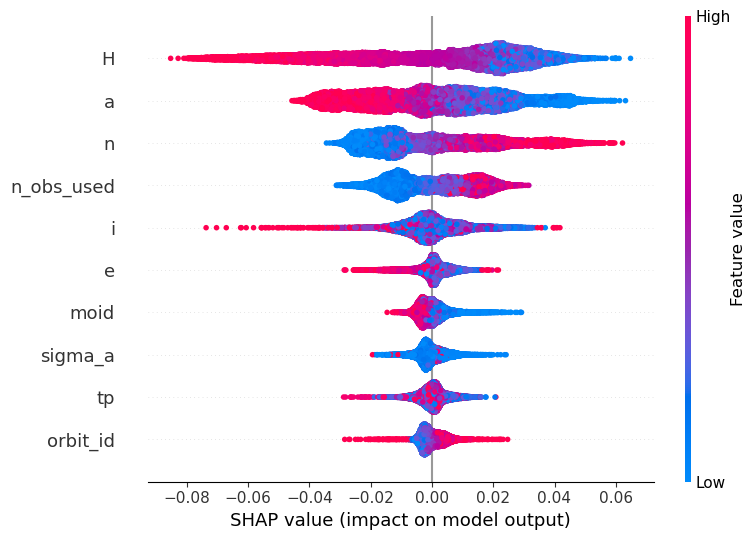

In [13]:
# --- SHAP analysis for model explainability ---

# Initialize SHAP explainer for the trained CatBoost model
explainer = shap.TreeExplainer(cat_reg_f)

# Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Plot summary of SHAP values showing top 10 features impacting predictions
shap.summary_plot(shap_values, X_test, max_display=10)

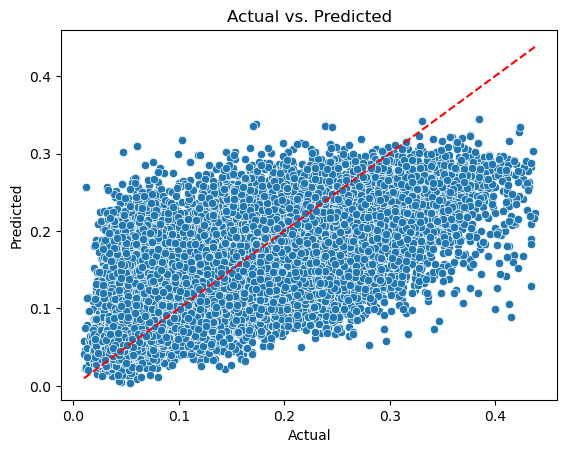

In [14]:
# --- Actual vs Predicted plots ---

# Plot predicted vs actual values on log-transformed scale
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

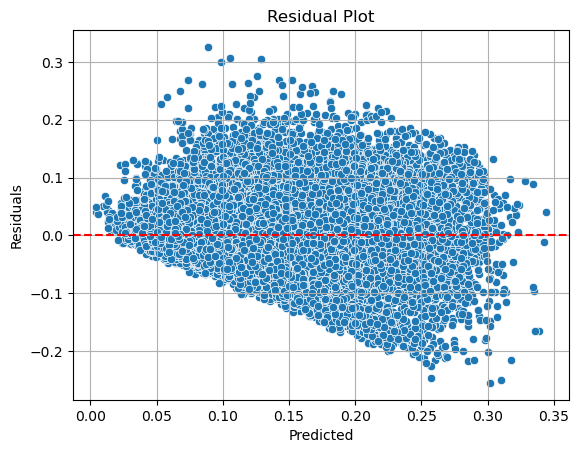

In [15]:
# --- Residual plots to diagnose errors ---
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

#### Imputing predicted albedo into asteroid dataset

In [16]:
# Imputing albedo in missing albedo values

# Select the same features as for training
X_all = asteroid.drop(columns=['albedo','diameter'])

# Predict albedo
predicted_albedo = cat_reg_f.predict(X_all)

# Round predicted diameter values to 3 decimal places
predicted_albedo_rounded = np.round(predicted_albedo, 3)

# Replace and overwrite albedo values with predictions in the original dataframe
asteroid['albedo_predicted'] = predicted_albedo_rounded

#### ML Model to predict and fill in "diameter" values

In [ ]:
# Extracting rows where diameter is present
ast_dia = asteroid[asteroid['diameter'].notna()]

# 'albedo' is dropped because we are using 'albedo_predicted' instead
ast_dia = ast_dia.drop(columns = ['albedo'])

In [18]:
# Apply log transformation
y_log = np.log1p(ast_dia['diameter'])

# Remove top 0.25% outliers
upper_bound = np.percentile(y_log, 99.75)
ast_dia_filtered = ast_dia[y_log <= upper_bound]

# Features and target
X_filtered = ast_dia_filtered.drop('diameter', axis=1)
y_filtered = np.log1p(ast_dia_filtered['diameter'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

### 🔍 Regression

We start with a basic linear regression model as a baseline. Then continue on to Random Forest, XGBoost, LightBGM and Catboost. After training, we evaluate performance using both log-transformed and original scale metrics.

In [19]:
# 📈 LINEAR REGRESSION
# Training a simple linear regression model to establish a baseline.

# Initialize and train the model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = lin_model.predict(X_test)
y_train_pred = lin_model.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

Train Mean Squared Error: 0.0277, R² Score: 0.8871
Test  Mean Squared Error: 0.0281, R² Score: 0.8883
Original Scale - Test MSE: 2.9188, R²: 0.8976


In [20]:
# Random forest regression
# Using Random Forest to capture nonlinear relationships and interactions.

# # Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

Train Mean Squared Error: 0.0034, R² Score: 0.9859
Test  Mean Squared Error: 0.0242, R² Score: 0.9038
Original Scale - Test MSE: 1.9787, R²: 0.9306


In [21]:
# XGBOOST REGRESSION
# Applying XGBoost for powerful gradient boosting with regularization.

# Initialize and train XGBRegressor
xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
xgb_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = xgb_reg.predict(X_test)
y_train_pred = xgb_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

Train Mean Squared Error: 0.0193, R² Score: 0.9212
Test  Mean Squared Error: 0.0236, R² Score: 0.9062
Original Scale - Test MSE: 2.3291, R²: 0.9183


In [22]:
# LightBGM REGRESSION
# Training LightGBM for efficient gradient boosting with fast training.

# Initialize and train LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(objective='regression', random_state=42)
lgb_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = lgb_reg.predict(X_test)
y_train_pred = lgb_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,013443 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4694
[LightGBM] [Info] Number of data points in the train set: 109484, number of used features: 31
[LightGBM] [Info] Start training from score 1,659920
Train Mean Squared Error: 0.0223, R² Score: 0.9090
Test  Mean Squared Error: 0.0235, R² Score: 0.9069
Original Scale - Test MSE: 1.9338, R²: 0.9322


In [23]:
# Catboost regression
# Utilizing CatBoost for handling categorical features and boosting accuracy.

# Initialize and train CatBoost Regressor
cat_reg = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)
cat_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = cat_reg.predict(X_test)
y_train_pred = cat_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.4835030	total: 8.05ms	remaining: 8.05s
200:	learn: 0.1590828	total: 1.15s	remaining: 4.58s
400:	learn: 0.1551280	total: 2.24s	remaining: 3.35s
600:	learn: 0.1530925	total: 3.31s	remaining: 2.2s
800:	learn: 0.1516866	total: 4.36s	remaining: 1.08s
999:	learn: 0.1505728	total: 5.42s	remaining: 0us
Train MSE: 0.0227, R²: 0.9074
Test  MSE: 0.0233, R²: 0.9075
Original Scale - Test MSE: 1.8798, R²: 0.9340


In [24]:
# Catboost regression
# Utilizing CatBoost for handling categorical features and boosting accuracy.

# Initialize and train CatBoost Regressor
cat_reg_f = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=7,
    loss_function='RMSE',
    l2_leaf_reg=7,
    random_seed=42,
    verbose=500
)
cat_reg_f.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = cat_reg_f.predict(X_test)
y_train_pred = cat_reg_f.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.4756527	total: 9.76ms	remaining: 19.5s
500:	learn: 0.1503679	total: 3.25s	remaining: 9.74s
1000:	learn: 0.1453232	total: 6.41s	remaining: 6.4s
1500:	learn: 0.1413121	total: 9.61s	remaining: 3.19s
1999:	learn: 0.1377817	total: 12.8s	remaining: 0us
Train MSE: 0.0190, R²: 0.9225
Test  MSE: 0.0223, R²: 0.9115
Original Scale - Test MSE: 1.8389, R²: 0.9355


In [25]:
# --- Cross-validation to check overfitting ---

# Compute R² scores for 5-fold cross-validation on filtered data

scores = cross_val_score(cat_reg_f, X_filtered, y_filtered, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Mean R²:", scores.mean())

0:	learn: 0.3834162	total: 10.6ms	remaining: 21.1s
500:	learn: 0.1456134	total: 3.46s	remaining: 10.4s
1000:	learn: 0.1405607	total: 6.71s	remaining: 6.69s
1500:	learn: 0.1365154	total: 10.4s	remaining: 3.44s
1999:	learn: 0.1330950	total: 14s	remaining: 0us
0:	learn: 0.4894045	total: 11.5ms	remaining: 22.9s
500:	learn: 0.1452472	total: 3.8s	remaining: 11.4s
1000:	learn: 0.1402816	total: 7.43s	remaining: 7.42s
1500:	learn: 0.1364324	total: 11s	remaining: 3.66s
1999:	learn: 0.1331070	total: 14.6s	remaining: 0us
0:	learn: 0.4990264	total: 12.4ms	remaining: 24.8s
500:	learn: 0.1487321	total: 3.84s	remaining: 11.5s
1000:	learn: 0.1434263	total: 7.68s	remaining: 7.66s
1500:	learn: 0.1393558	total: 11.6s	remaining: 3.86s
1999:	learn: 0.1358337	total: 15.5s	remaining: 0us
0:	learn: 0.5018024	total: 11.3ms	remaining: 22.6s
500:	learn: 0.1539059	total: 3.8s	remaining: 11.4s
1000:	learn: 0.1485006	total: 7.53s	remaining: 7.51s
1500:	learn: 0.1442870	total: 11.2s	remaining: 3.73s
1999:	learn: 0.14

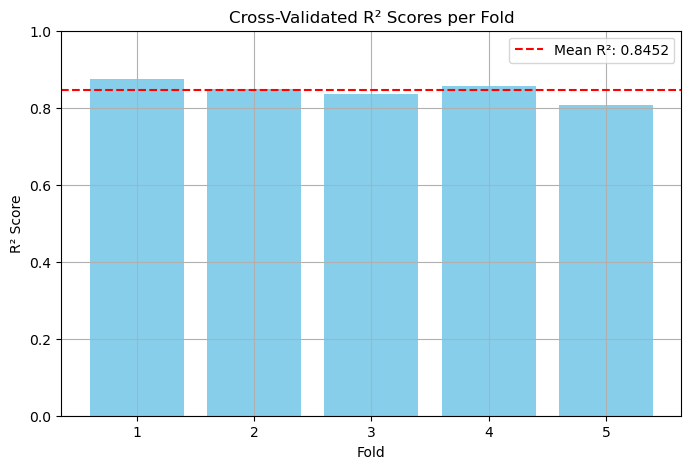

In [29]:
# CV scores
r2_scores = [0.87582358, 0.84991456, 0.83638781, 0.8564713, 0.80728461]

# Plot R² scores for each fold to visually inspect model consistency
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(r2_scores) + 1), r2_scores, color='skyblue')
plt.axhline(np.mean(r2_scores), color='red', linestyle='--', label=f'Mean R²: {np.mean(r2_scores):.4f}')
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Cross-Validated R² Scores per Fold')
plt.legend()
plt.grid(True)
plt.show()

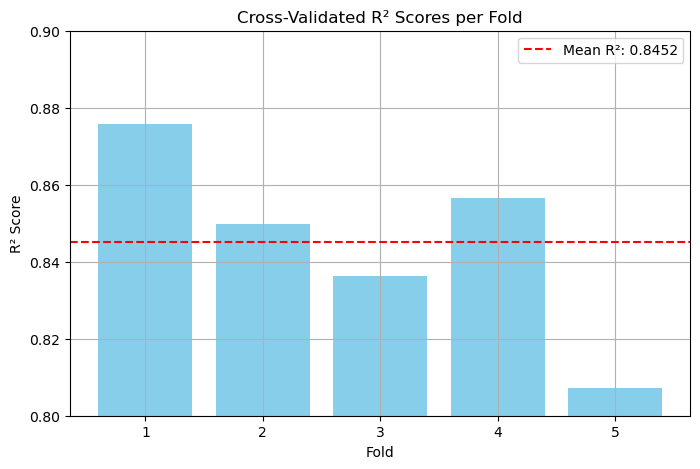

In [26]:
# CV scores
r2_scores = [0.87582358, 0.84991456, 0.83638781, 0.8564713, 0.80728461]

# Plot R² scores for each fold to visually inspect model consistency
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(r2_scores) + 1), r2_scores, color='skyblue')
plt.axhline(np.mean(r2_scores), color='red', linestyle='--', label=f'Mean R²: {np.mean(r2_scores):.4f}')
plt.ylim(0.8, 0.9)
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Cross-Validated R² Scores per Fold')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# --- Feature importance from CatBoost ---

# Get feature importance with readable format
cat_reg_f.get_feature_importance(prettified=True)

,Feature Id,Importances
0,H,63.588168
1,albedo_predicted,22.421790
2,n,2.248270
3,a,1.784536
4,i,1.648816
5,n_obs_used,1.624659
6,sigma_a,0.691534
7,moid,0.640137
8,data_arc,0.613756
9,e,0.595229


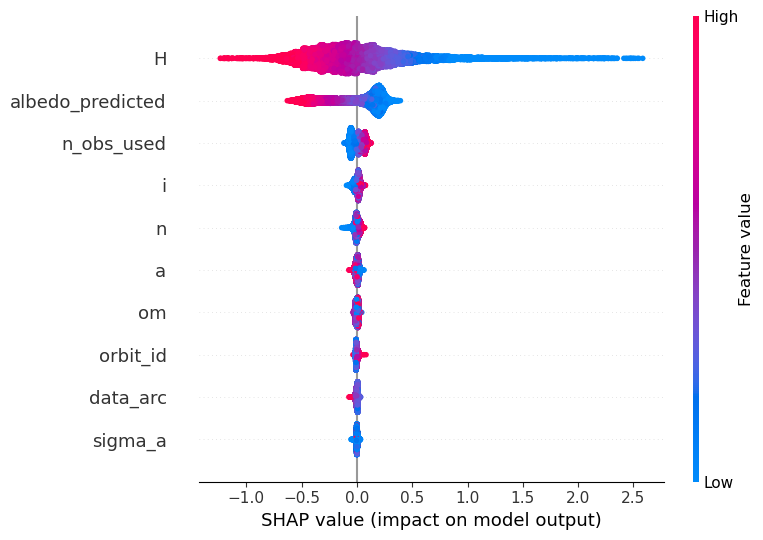

In [31]:
# --- SHAP analysis for model explainability ---

# Initialize SHAP explainer for the trained CatBoost model
explainer = shap.TreeExplainer(cat_reg_f)

# Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Plot summary of SHAP values showing top 10 features impacting predictions
shap.summary_plot(shap_values, X_test, max_display=10)

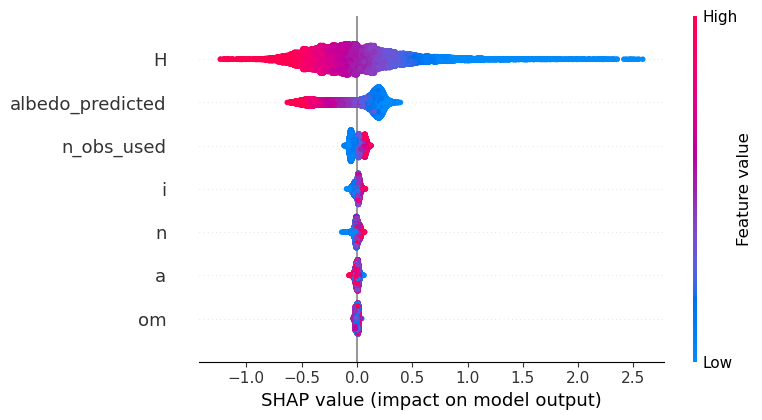

In [32]:
# --- SHAP analysis for model explainability ---

# Initialize SHAP explainer for the trained CatBoost model
explainer = shap.TreeExplainer(cat_reg_f)

# Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Plot summary of SHAP values showing top 7 features impacting predictions
shap.summary_plot(shap_values, X_test, max_display=7)

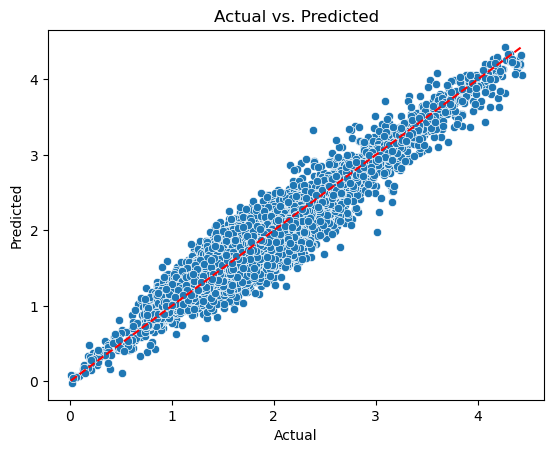

In [33]:
# --- Actual vs Predicted plots ---

# Plot predicted vs actual values on log-transformed scale
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

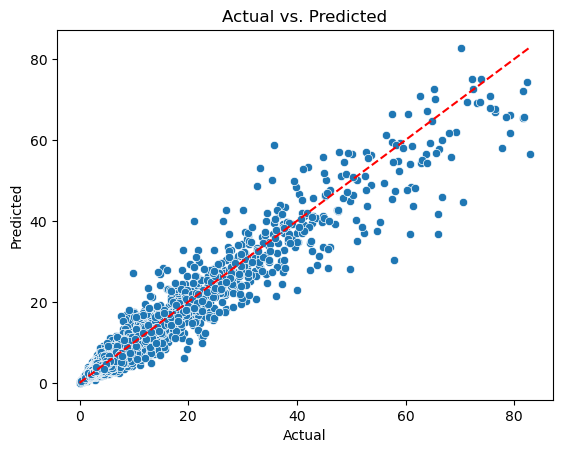

In [34]:
# Plot predicted vs actual values on original scale (inverse transformed)
sns.scatterplot(x=y_test_original, y=y_pred_original)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

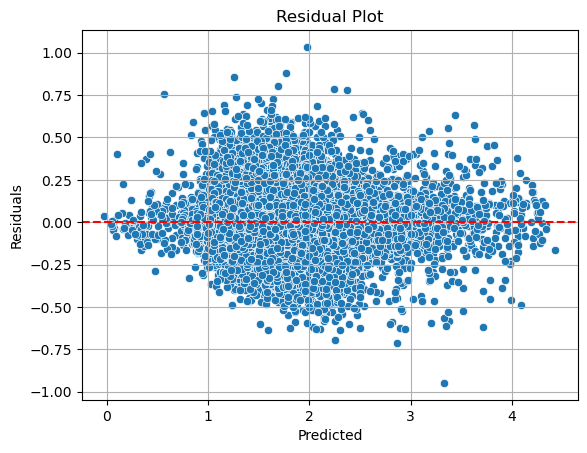

In [35]:
# --- Residual plots to diagnose errors ---

# Residuals on log-transformed scale
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

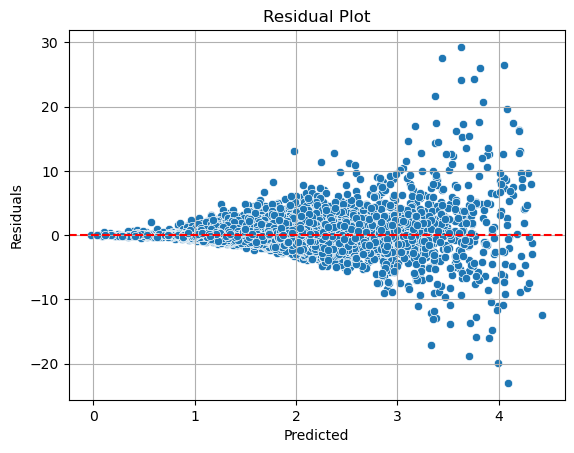

In [36]:
# Residuals on original scale
residuals = y_test_original - y_pred_original

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

In [37]:
# Quantile regression 0.1 alpha

cat_quantile = CatBoostRegressor(
    loss_function='Quantile:alpha=0.1',
    iterations=2000,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=7,
    random_seed=42,
    verbose=500
)

cat_quantile.fit(X_train, y_train)

# Predict on test and train set
y_pred = cat_quantile.predict(X_test)
y_train_pred = cat_quantile.predict(X_train)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics (already computed)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print both
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# Inverse transform
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Metrics on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.0679159	total: 10.4ms	remaining: 20.7s
500:	learn: 0.0227014	total: 4.74s	remaining: 14.2s
1000:	learn: 0.0220770	total: 8.95s	remaining: 8.93s
1500:	learn: 0.0217855	total: 13s	remaining: 4.32s
1999:	learn: 0.0215943	total: 17s	remaining: 0us
Train Mean Squared Error: 0.0563, R² Score: 0.7701
Test  Mean Squared Error: 0.0569, R² Score: 0.7740
Original Scale - Test MSE: 4.2326, R²: 0.8515


In [38]:
# Quantile regression 0.5 alpha

cat_quantile = CatBoostRegressor(
    loss_function='Quantile:alpha=0.5',
    iterations=2000,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=7,
    random_seed=42,
    verbose=500
)

cat_quantile.fit(X_train, y_train)

# Predict on test and train set
y_pred = cat_quantile.predict(X_test)
y_train_pred = cat_quantile.predict(X_train)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics (already computed)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print both
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# Inverse transform
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Metrics on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.1761200	total: 15ms	remaining: 30s
500:	learn: 0.0547509	total: 5.1s	remaining: 15.3s
1000:	learn: 0.0530574	total: 10.1s	remaining: 10s
1500:	learn: 0.0519025	total: 15.1s	remaining: 5.02s
1999:	learn: 0.0510671	total: 20s	remaining: 0us
Train Mean Squared Error: 0.0221, R² Score: 0.9098
Test  Mean Squared Error: 0.0238, R² Score: 0.9055
Original Scale - Test MSE: 1.9243, R²: 0.9325


In [39]:
# Quantile regression 0.9 alpha

cat_quantile = CatBoostRegressor(
    loss_function='Quantile:alpha=0.9',
    iterations=2000,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=7,
    random_seed=42,
    verbose=500
)

cat_quantile.fit(X_train, y_train)

# Predict on test and train set
y_pred = cat_quantile.predict(X_test)
y_train_pred = cat_quantile.predict(X_train)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics (already computed)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print both
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# Inverse transform
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Metrics on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.0983995	total: 12.9ms	remaining: 25.9s
500:	learn: 0.0252865	total: 4.84s	remaining: 14.5s
1000:	learn: 0.0245483	total: 9.68s	remaining: 9.66s
1500:	learn: 0.0243363	total: 14.2s	remaining: 4.72s
1999:	learn: 0.0242818	total: 18.4s	remaining: 0us
Train Mean Squared Error: 0.0600, R² Score: 0.7552
Test  Mean Squared Error: 0.0617, R² Score: 0.7551
Original Scale - Test MSE: 4.5133, R²: 0.8416


#### Filling missing diameters by predicted 'diameter' into asteroid dataset

In [42]:
# Filling in missing diameter values

# Prepare input data
missing_diameter = asteroid[asteroid['diameter'].isna()].copy()

# Select the same features as for training
missing_X = missing_diameter.drop(columns=['diameter','albedo'])

# Predict diameter
predicted_diameter = cat_reg_f.predict(missing_X)

# Round predicted diameter values to 3 decimal places
predicted_diameter_rounded = np.round(predicted_diameter, 3)

# Replace missing values in the original dataframe
asteroid.loc[missing_X.index, 'diameter'] = predicted_diameter_rounded

#### 💾 Save Completed Dataset

In [43]:
# Save dataset as a csv file for last modelling
asteroid.to_csv("data/asteroid_complete.csv",index=True)